# ABI

$\Xi$

In [213]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from tqdm import tqdm

In [214]:
def prospect_value_function(x: float, alpha=0.8, beta=0.8, lam=2.25) -> float:
    if x >= 0:
        return x ** alpha
    
    return -lam * ((-x) ** beta)

In [215]:
def logit_activation(x: np.array) -> np.array:
    exp_input = np.exp(x)
    exp_input_sum = np.sum(exp_input)

    return exp_input / exp_input_sum

In [216]:
class Provider:
    def __init__(self, name: str, p: np.array):
        self.name = name
        self.p = p

    def __repr__(self):
        return f"Provider '{self.name}': {self.p}"

In [217]:
class Agent:
    def __init__(self, w: np.array, ref: np.array):
        self.w = np.reshape(w, (1, len(w))) 
        self.ref = ref
        self.current_provider = -1

    def utility_for(self, option: np.array):
        deltas = option - self.ref
        prospect_activation = np.array([prospect_value_function(x) for x in deltas])

        return (self.w @ prospect_activation).item()
    
    def activated_output_for(self, providers: List[Provider], actiavtion_func) -> np.array:
        utilities = np.array([self.utility_for(provider.p) for provider in providers])
        return actiavtion_func(utilities)
    
    def __repr__(self):
        return f"Agent[w={np.round(self.w, 2)}, ref={np.round(self.ref, 2)}, current_provider={self.current_provider}]"

In [218]:
rules = {
    'price': {
        'min': 0,
        'max': 100,
        'expected': 50,
        'std': 15
    },
    'connection_speed': {
        'min': 0,
        'max': 1_000,
        'expected': 100,
        'std': 15
    },
    'quality': {
        'min': 0,
        'max': 100,
        'expected': 50,
        'std': 15
    },
}

def normalize(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return (value - mn) / (mx - mn)

def clip_to_bounds(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return float(np.clip(value, mn, mx))

In [219]:
def init_agents(amount: int) -> List[Agent]:
    weights = np.array([-0.15, 0.25, 0.3]) / 0.7
    res = []

    for _ in range(amount):
        price_ref = np.random.normal(rules['price']['expected'], rules['price']['std'])
        speed_ref = np.random.normal(rules['connection_speed']['expected'], rules['connection_speed']['std'])
        quality_ref = np.random.normal(rules['quality']['expected'], rules['quality']['std'])

        price_ref = clip_to_bounds(price_ref, 'price')
        speed_ref = clip_to_bounds(speed_ref, 'connection_speed')
        quality_ref = clip_to_bounds(quality_ref, 'quality')

        ref = np.array([
            normalize(price_ref, 'price'),
            normalize(speed_ref, 'connection_speed'),
            normalize(quality_ref, 'quality')
        ])

        res.append(Agent(weights, ref))

    return res


In [220]:
def init_providers() -> List[Provider]:
    res = []

    res.append(Provider("Wir", np.array(
        [
            normalize(70, 'price'),
            normalize(600, 'connection_speed'),
            normalize(70, 'quality')
        ])))
    
    res.append(Provider("Competitior1", np.array(
        [
            normalize(40, 'price'),
            normalize(100, 'connection_speed'),
            normalize(40, 'quality')
        ])))
    
    res.append(Provider("Competitior2", np.array(
        [
            normalize(90, 'price'),
            normalize(900, 'connection_speed'),
            normalize(75, 'quality')
        ])))

    return res


In [221]:
M = 1_000
T = 52
SWITCH_COST = 0.5

In [222]:
agents = init_agents(M)

agents[0:5]

[Agent[w=[[-0.21  0.36  0.43]], ref=[0.61 0.12 0.55], current_provider=-1],
 Agent[w=[[-0.21  0.36  0.43]], ref=[0.64 0.11 0.33], current_provider=-1],
 Agent[w=[[-0.21  0.36  0.43]], ref=[0.49 0.1  0.48], current_provider=-1],
 Agent[w=[[-0.21  0.36  0.43]], ref=[0.27 0.1  0.47], current_provider=-1],
 Agent[w=[[-0.21  0.36  0.43]], ref=[0.53 0.11 0.64], current_provider=-1]]

In [223]:
providers = init_providers()

providers

[Provider 'Wir': [0.7 0.6 0.7],
 Provider 'Competitior1': [0.4 0.1 0.4],
 Provider 'Competitior2': [0.9  0.9  0.75]]

In [224]:
agent = agents[0]
for p in providers:
    print(agent.utility_for(p.p))
print(agent.activated_output_for(providers, logit_activation))

0.26051001874102453
-0.10651507892244447
0.3308434590142416
[0.36157759 0.25049816 0.38792425]


In [225]:
market_share_history = np.ndarray(shape=(T, len(providers)))

providers_idxes = np.arange(0, len(providers))

for t in tqdm(range(T)):
    agent_choices = np.zeros(shape=len(providers))

    for agent in agents:
        utilities = np.array([agent.utility_for(provider.p) for provider in providers])

        if agent.current_provider != -1:
            for i in providers_idxes:
                if i != agent.current_provider:
                    utilities[i] -= SWITCH_COST


        logit_probs = logit_activation(utilities)

        choice = np.random.choice(providers_idxes, p=logit_probs)
        agent_choices[choice] += 1
        provider = providers[choice]
        agent.ref = provider.p
        agent.current_provider = choice
    
    market_share_history[t] = agent_choices / M


        

100%|██████████| 52/52 [00:04<00:00, 12.79it/s]


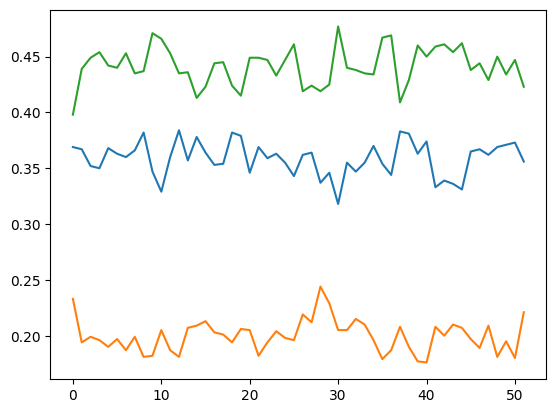

In [226]:
plt.plot(market_share_history)